<a href="https://colab.research.google.com/github/Gh4n5kH/mugni-data-science-2024/blob/main/Pertemuan12_Mugni_240401010355.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Muhamad Mugni Abdul Gani**

**NIM: 240401010355**

**Kelas: IF405**

==============================

**Langkah 1: Generate & Eksplorasi Dataset Transaksi**

Contoh transaksi:
[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
[np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
[np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]

Jumlah transaksi: 50

Frekuensi Produk:
    Produk  Frekuensi
4    Selai         26
5      Teh         23
2  Mentega         21
7    Telur         18
0     Keju         17
1     Roti         16
3     Kopi         16
6     Susu         16
8     Gula         16
9   Sereal          9


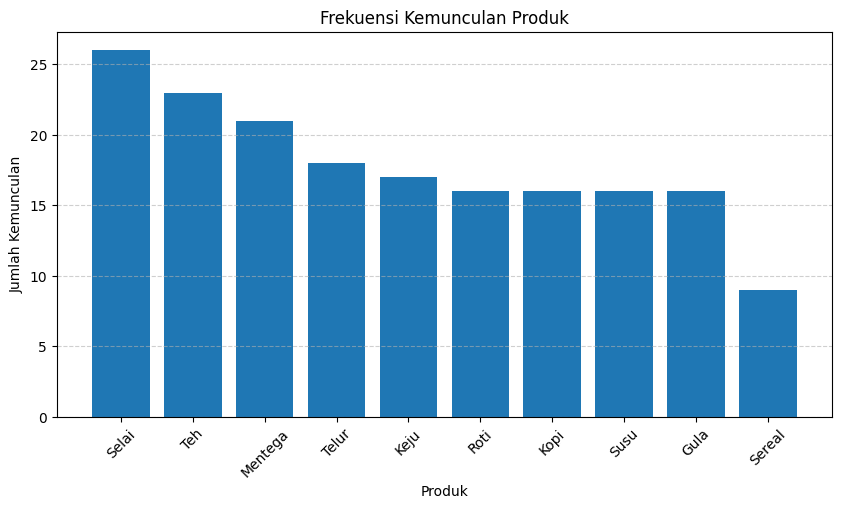

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
           'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi:")
for t in transaksi[:3]:
    print(t)

print("\nJumlah transaksi:", len(transaksi))

# ================================
# Eksplorasi Frekuensi Produk
# ================================

# Hitung frekuensi setiap produk
counter = Counter()

for trx in transaksi:
    counter.update(trx)

# Ubah menjadi DataFrame
df_freq = pd.DataFrame(
    counter.items(),
    columns=['Produk', 'Frekuensi']
).sort_values(by='Frekuensi', ascending=False)

print("\nFrekuensi Produk:")
print(df_freq)

# Visualisasi

plt.figure(figsize=(10,5))
plt.bar(df_freq['Produk'], df_freq['Frekuensi'])
plt.title("Frekuensi Kemunculan Produk")
plt.xlabel("Produk")
plt.ylabel("Jumlah Kemunculan")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Langkah 2: One-Hot Encoding Transaksi**

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# One-Hot Encoding transaksi
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

# Membuat DataFrame
df = pd.DataFrame(te_ary, columns=te.columns_)

# Menampilkan 5 baris pertama
print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


**Langkah 3: Cari Frequent Itemset dengan Apriori**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori

# Jalankan Apriori dengan beberapa nilai min_support
for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f"min_support = {ms}: {len(freq)} itemset ditemukan")

# Gunakan min_support = 0.1
freq_items = apriori(df, min_support=0.1, use_colnames=True)

# Urutkan berdasarkan support terbesar
freq_items = freq_items.sort_values(by="support", ascending=False)

print("\n10 Frequent Itemset Teratas")
print(freq_items.head(10))

min_support = 0.05: 74 itemset ditemukan
min_support = 0.1: 44 itemset ditemukan
min_support = 0.2: 13 itemset ditemukan

10 Frequent Itemset Teratas
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


**Langkah 4: Bentuk & Saring Aturan Asosiasi**

In [ ]:
from mlxtend.frequent_patterns import association_rules

# Membentuk aturan asosiasi
rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

# Filter aturan dengan Lift > 1
rules = rules[rules["lift"] > 1]

# Urutkan berdasarkan Lift tertinggi
rules = rules.sort_values(by="lift", ascending=False)

# Tampilkan 10 aturan terbaik
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

         antecedents consequents  support  confidence      lift
9        (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
13  (Mentega, Selai)      (Kopi)     0.10    0.625000  1.953125
12      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
10      (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
15     (Selai, Kopi)   (Mentega)     0.10    0.714286  1.700680
8      (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
11     (Gula, Selai)      (Roti)     0.10    0.500000  1.562500
14   (Mentega, Kopi)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


## Interpretasi Association Rules

Berdasarkan hasil Association Rule Mining menggunakan algoritma Apriori, aturan dengan nilai **Lift tertinggi** adalah:

**Roti → Selai**

- Aturan tersebut memiliki nilai Lift lebih dari 1, yang menunjukkan bahwa produk Roti dan Selai memiliki hubungan positif. Artinya, pelanggan yang membeli Roti memiliki kemungkinan lebih besar untuk membeli Selai dibandingkan pelanggan secara umum.

- Hal ini masuk akal secara bisnis karena Roti dan Selai merupakan produk yang sering dikonsumsi secara bersamaan. Oleh karena itu, kedua produk dapat ditempatkan berdekatan di rak supermarket atau dijadikan paket promosi (bundling) untuk meningkatkan penjualan.

**Langkah 5: Rekomender Sederhana dengan Content-Based Filtering**

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Katalog produk
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
        'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
    ]
})

# One-Hot Encoding kategori
fitur = pd.get_dummies(katalog['kategori'])

# Hitung Cosine Similarity
sim_matrix = cosine_similarity(fitur)

# Fungsi rekomendasi produk serupa
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]

    # Hitung skor similarity
    skor = list(enumerate(sim_matrix[idx]))

    # Urutkan dari similarity tertinggi
    skor = sorted(skor, key=lambda x: x[1], reverse=True)

    # Hilangkan produk itu sendiri
    skor = [s for s in skor if s[0] != idx][:top_n]

    # Ambil nama produk
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

# Contoh rekomendasi
print("Mirip dengan Roti:", rekomendasi_serupa("Roti"))
print("Mirip dengan Susu:", rekomendasi_serupa("Susu"))
print("Mirip dengan Kopi:", rekomendasi_serupa("Kopi"))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu: ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi: ['Teh', 'Roti', 'Selai']


**Langkah 6: Bandingkan Kedua Pendekatan**

In [ ]:
# Produk yang ingin dibandingkan rekomendasinya
produk_target = "Roti"

# Association Rules
rules_terkait = rules[
    rules["antecedents"].apply(lambda x: produk_target in x)
]

print("=== Rekomendasi dari Association Rules ===")

if len(rules_terkait) > 0:
    print(
        rules_terkait[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ].head()
    )
else:
    print("Tidak ada aturan yang ditemukan.")


# Content-Based
print("\n=== Rekomendasi dari Content-Based ===")
print(rekomendasi_serupa(produk_target))

=== Rekomendasi dari Association Rules ===
     antecedents consequents  support  confidence      lift
12  (Roti, Gula)     (Selai)     0.10      1.0000  1.923077
1         (Roti)     (Selai)     0.22      0.6875  1.322115

=== Rekomendasi dari Content-Based ===
['Selai', 'Sereal', 'Susu']


### 1. Apakah kedua pendekatan memberikan rekomendasi yang konsisten?

Ya, sebagian konsisten.

- Sebagai contoh, kedua metode sama-sama merekomendasikan **Selai** untuk produk **Roti**. Hal ini menunjukkan bahwa Selai memiliki hubungan yang kuat dengan Roti, baik berdasarkan pola pembelian pelanggan maupun berdasarkan karakteristik produk.

- Namun, terdapat perbedaan pada rekomendasi lainnya. Metode Association Rules merekomendasikan produk yang sering dibeli bersamaan, sedangkan Content-Based merekomendasikan produk yang memiliki kategori yang sama.

### 2. Kapan sebaiknya menggunakan salah satu, atau menggabungkan keduanya (Hybrid)?
- Gunakan Association Rules jika sudah memiliki banyak data transaksi, sehingga dapat mengetahui kebiasaan belanja pelanggan.
- Gunakan Content-Based jika data transaksi masih sedikit atau ada produk baru yang belum pernah dibeli.
- Gunakan Hybrid (gabungan keduanya) jika ingin mendapatkan rekomendasi yang lebih akurat. Metode ini memanfaatkan pola pembelian pelanggan sekaligus kemiripan antar produk, sehingga hasil rekomendasinya menjadi lebih lengkap dan relevan.